In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("../data/UNSW_NB15_training-set.csv")
test  = pd.read_csv("../data/UNSW_NB15_testing-set.csv")

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("\nColumns:")
print(train.columns.tolist())

Train shape: (175341, 45)
Test shape : (82332, 45)

Columns:
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [2]:
print("Train label counts:")
print(train["label"].value_counts().sort_index())

print("\nTest label counts:")
print(test["label"].value_counts().sort_index())

print("\nMissing values in train (top 15):")
print(train.isna().sum().sort_values(ascending=False).head(15))

print("\nMissing values in test (top 15):")
print(test.isna().sum().sort_values(ascending=False).head(15))

print("\nCategorical columns:")
print(train.select_dtypes(include=["object"]).columns.tolist())

Train label counts:
label
0     56000
1    119341
Name: count, dtype: int64

Test label counts:
label
0    37000
1    45332
Name: count, dtype: int64

Missing values in train (top 15):
id         0
dur        0
proto      0
service    0
state      0
spkts      0
dpkts      0
sbytes     0
dbytes     0
rate       0
sttl       0
dttl       0
sload      0
dload      0
sloss      0
dtype: int64

Missing values in test (top 15):
id         0
dur        0
proto      0
service    0
state      0
spkts      0
dpkts      0
sbytes     0
dbytes     0
rate       0
sttl       0
dttl       0
sload      0
dload      0
sloss      0
dtype: int64

Categorical columns:
['proto', 'service', 'state', 'attack_cat']


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

AttacK vs Normal Distribution

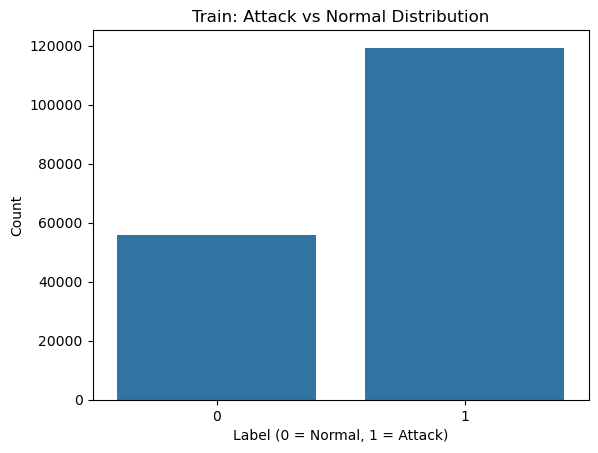

In [4]:
sns.countplot(x=train["label"])
plt.title("Train: Attack vs Normal Distribution")
plt.xlabel("Label (0 = Normal, 1 = Attack)")
plt.ylabel("Count")
plt.show()

Attack Categories

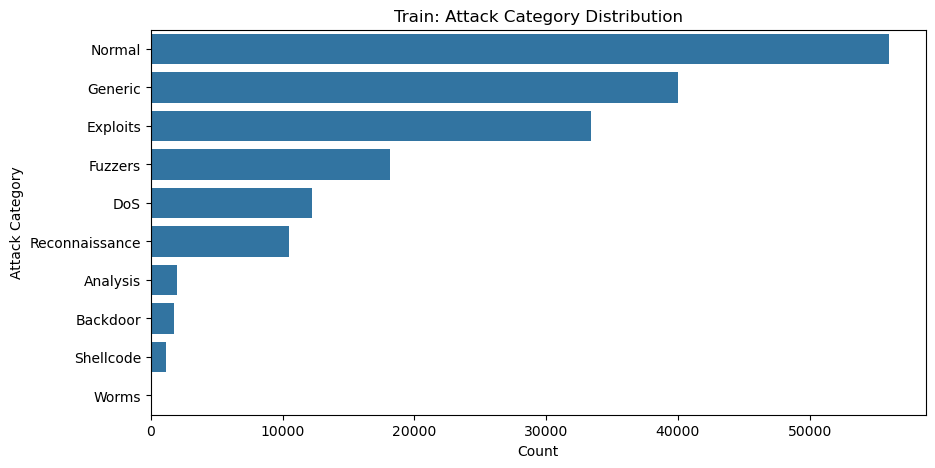

In [5]:
plt.figure(figsize=(10, 5))
sns.countplot(y=train["attack_cat"], order=train["attack_cat"].value_counts().index)
plt.title("Train: Attack Category Distribution")
plt.xlabel("Count")
plt.ylabel("Attack Category")
plt.show()

Protocol Distribution

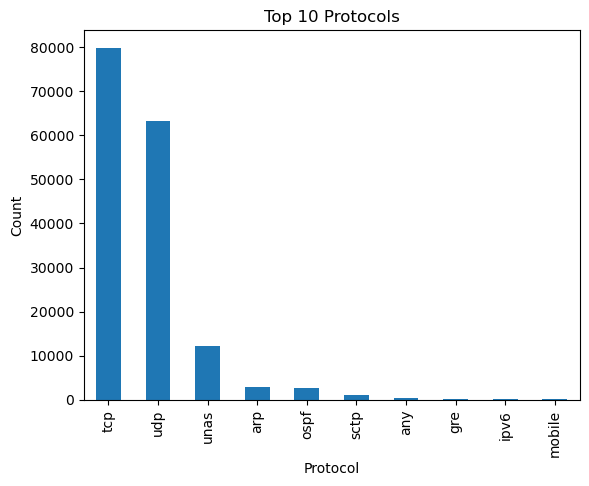

In [6]:
top_proto = train["proto"].value_counts().head(10)
top_proto.plot(kind="bar")
plt.title("Top 10 Protocols")
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.show()

Correlation Heatmap

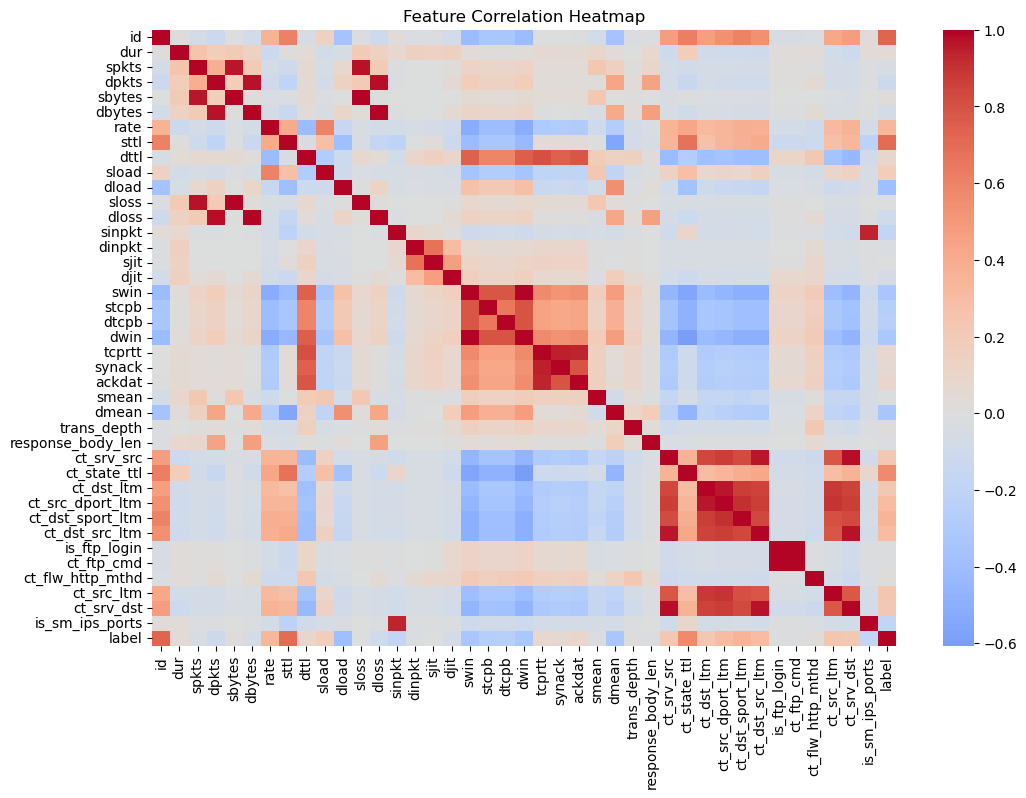

In [7]:
plt.figure(figsize=(12, 8))
corr = train.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

Packet Distribution

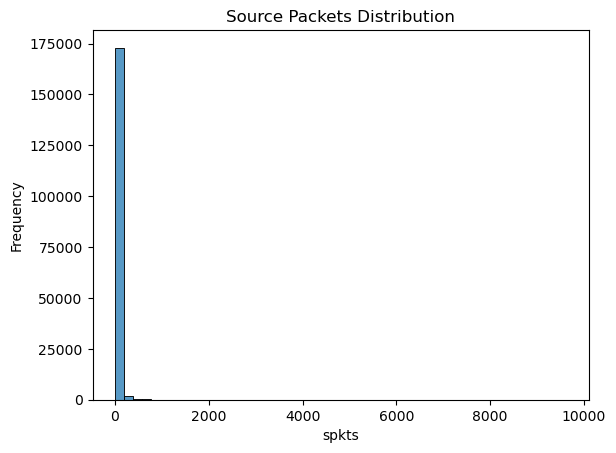

In [8]:
sns.histplot(train["spkts"], bins=50)
plt.title("Source Packets Distribution")
plt.xlabel("spkts")
plt.ylabel("Frequency")
plt.show()